In [1]:
import numpy as np 
import pandas as pd 
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
from learntools.time_series.style import *  
from learntools.time_series.utils import plot_lags, make_lags, make_leads
from sklearn.multioutput import RegressorChain
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
 

/kaggle/input/web-traffic-time-series-forecasting/sample_submission_2.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/sample_submission_1.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/train_2.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/key_1.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/key_2.csv.zip
/kaggle/input/web-traffic-time-series-forecasting/train_1.csv.zip


Commençons par visualiser l'ensemble de nos fichiers :

On les importe :

In [2]:
path1 = "/kaggle/input/web-traffic-time-series-forecasting/train_2.csv.zip"
path2 = "/kaggle/input/web-traffic-time-series-forecasting/key_1.csv.zip"
path3 = "/kaggle/input/web-traffic-time-series-forecasting/key_2.csv.zip"
path4 = "/kaggle/input/web-traffic-time-series-forecasting/train_1.csv.zip"

train2 = pd.read_csv(path1)
key1 = pd.read_csv(path2)
key2 = pd.read_csv(path3)
train1= pd.read_csv(path4)

In [3]:
key1.head()

,Page,Id
0,!vote_en.wikipedia.org_all-access_all-agents_2...,bf4edcf969af
1,!vote_en.wikipedia.org_all-access_all-agents_2...,929ed2bf52b9
2,!vote_en.wikipedia.org_all-access_all-agents_2...,ff29d0f51d5c
3,!vote_en.wikipedia.org_all-access_all-agents_2...,e98873359be6
4,!vote_en.wikipedia.org_all-access_all-agents_2...,fa012434263a


In [4]:
train1.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


Pour le moment nous allons nous intérésser à une seule TS parmie les 145 000. 

Prenons la première par exemple.

In [5]:
article1 = train1.iloc[0,1:]  # Il s'agit de la première ligne de train1 : 2NE1_zh.wikipedia.org_all-access_spider

valeurs_manquantes =article1[pd.isnull(article1)]

print(valeurs_manquantes)

Series([], Name: 0, dtype: object)


**Il n'y a aucune valeur manquante ici.**

On affiche un graphique du nombre de vues de ce site selon la date : 

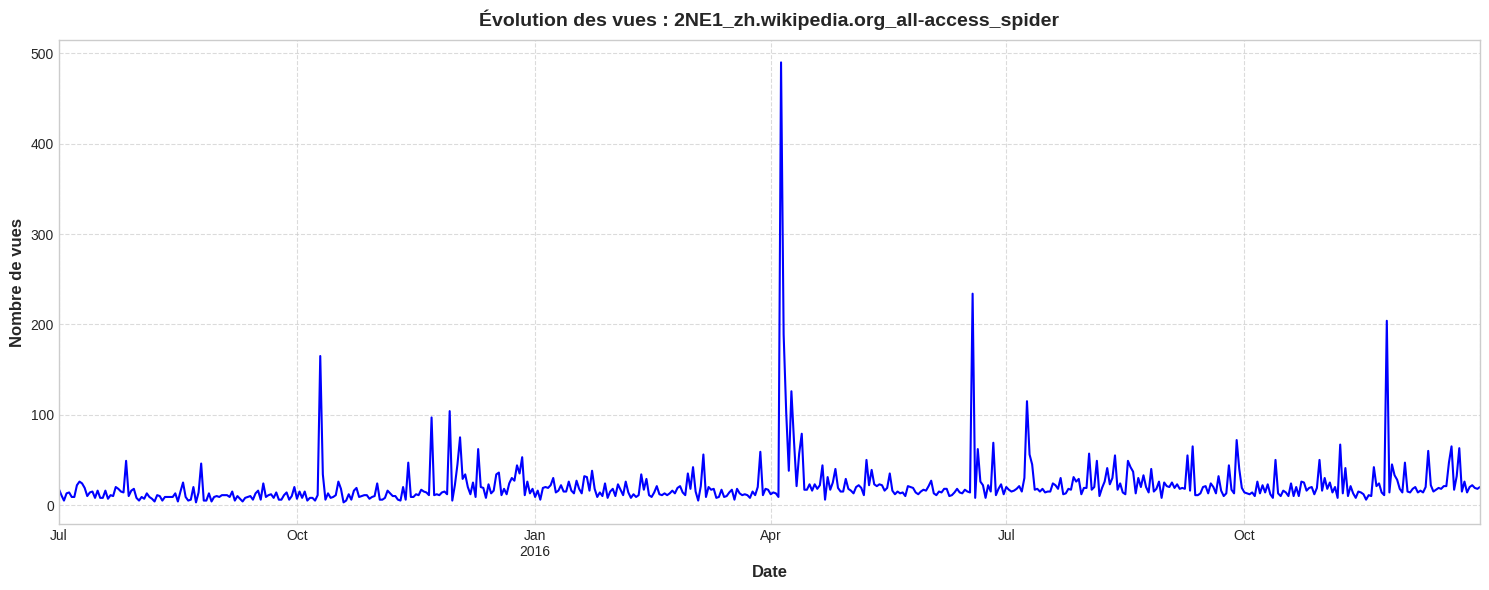

In [6]:
article1.index = pd.to_datetime(article1.index)

plt.figure(figsize=(15, 6))
article1.plot(color='blue', linewidth=1.5)
plt.title(f"Évolution des vues : {train1.iloc[0, 0]}", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Nombre de vues", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

On lisse la courbe :

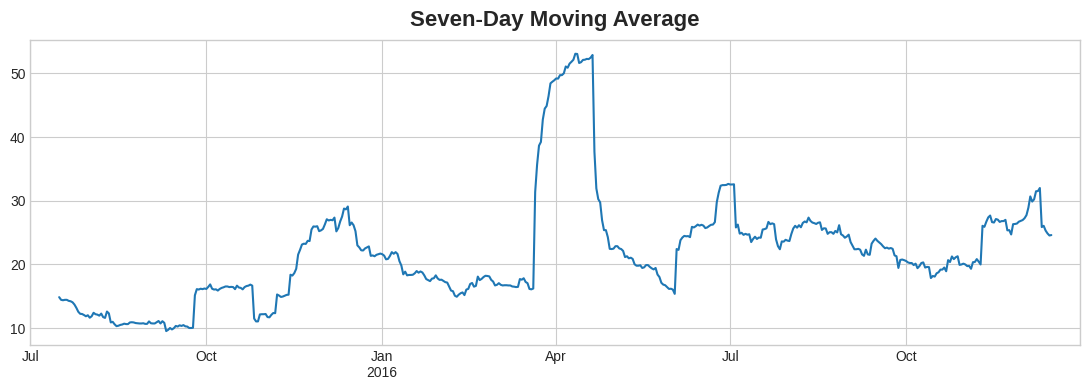

In [7]:
y_ma = article1.rolling(
    window=31,       # fenetre de 31 jours
    center=True,     
).mean()     

ax = y_ma.plot()
ax.set_title("Seven-Day Moving Average");

Vérifions si nous trouvons des cycles ou des saisonalités particulières.

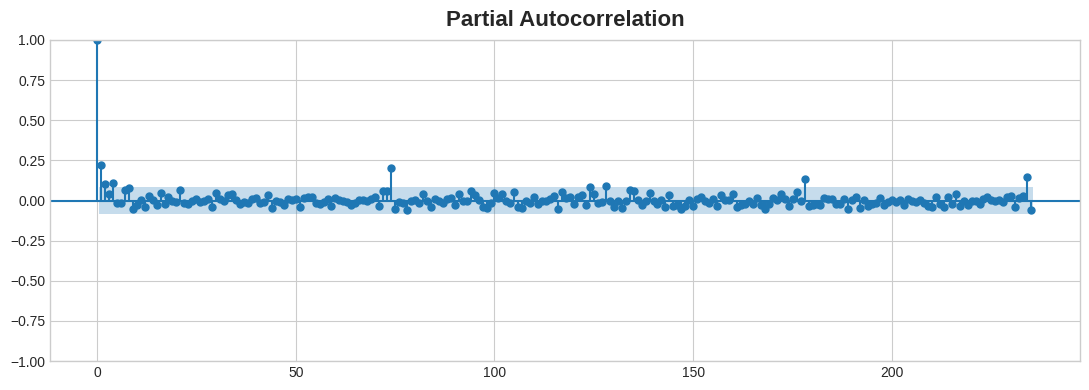

In [8]:
plot_pacf(article1, lags=235);
# 1 ; 74 ; 178 ; 234  -> 0.25 ; 0.23 ; 0.13 ; 0:15

Les valeurs  74 ; 178 ; 234 ont un coefficiant d'autocorélation partielle supérieurs ou égal à 0.13 :  (1 ; 74 ; 178 ; 234  -> 0.25 ; 0.23 ; 0.13 ; 0:15).

Créeons X, notre colonne avec nos lags :

In [9]:
def make_custom_lags(ts,lag_list):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in lag_list
        },
        axis=1)
mes_lags = [1, 74,178, 234]

X = make_custom_lags(article1, lag_list=mes_lags)
X.fillna(0.0, inplace = True)

def make_multistep_target(ts, steps):
    return pd.concat(
        {f'y_step_{i}':ts.shift(-i) for i in range(0, steps)},
        axis=1)

# On crée notre cible de 16 jours
y = make_multistep_target(article1, steps=16)

y, X = y.align(X,join='inner', axis=0)

Créeons notre modèle : 

In [10]:
data_clean = pd.concat([X,y],axis=1).dropna()
# On sépare à nouveau
X_final = data_clean[X.columns]
y_final = data_clean[y.columns]
 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final,test_size= 16 , shuffle=False)

model = RegressorChain(base_estimator=XGBRegressor())
model.fit(X_train, y_train) 

RegressorChain(base_estimator=XGBRegressor(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate=None, max_bin=None,
                                           max_cat_threshold=None,
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...))

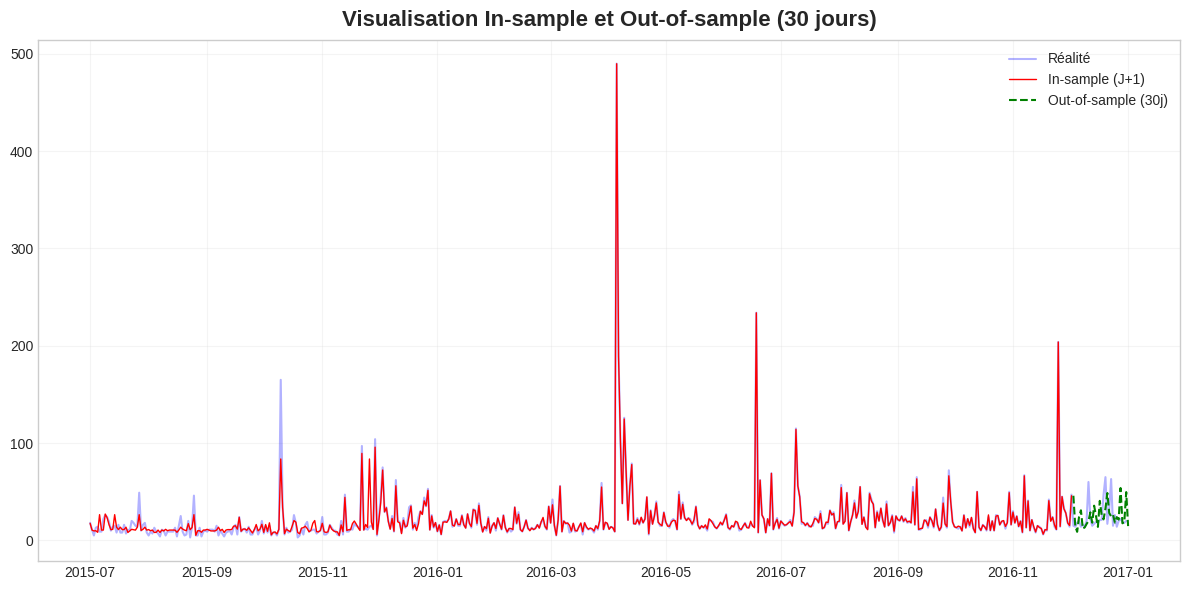

Prédictions Out-of-sample (30 jours) :
2016-12-03    45.850632
2016-12-04    14.664350
2016-12-05     8.785525
2016-12-06    24.058254
2016-12-07    30.908325
2016-12-08    12.151241
2016-12-09    13.311137
2016-12-10    16.880926
2016-12-11    19.860659
2016-12-12    28.756073
2016-12-13    18.164114
2016-12-14    35.626812
2016-12-15    24.956623
2016-12-16    13.851099
2016-12-17    40.590561
2016-12-18    25.532919
2016-12-19    21.555960
2016-12-20    32.828754
2016-12-21    48.629539
2016-12-22    28.182789
2016-12-23    24.699474
2016-12-24    26.444191
2016-12-25    18.263262
2016-12-26    23.891369
2016-12-27    21.350632
2016-12-28    53.787533
2016-12-29    17.549959
2016-12-30    19.044634
2016-12-31    49.607670
2017-01-01    14.668686
Freq: D, dtype: float64


In [11]:
# Définissons n et préparons les données 
n = 30 # 

y = make_multistep_target(article1, steps=n)
data_clean = pd.concat([X,y],axis=1).dropna()
X_final = data_clean[X.columns]
y_final =data_clean[y.columns]

# Ré-entraînons le modèle avec le nouveau n
model = RegressorChain(base_estimator=XGBRegressor())
model.fit(X_final,y_final)

# On fait notre pred
y_pred = pd.DataFrame(model.predict(X_final),index=X_final.index, columns=[f'Jour_{i+1}' for i in range(n)]).clip(0.0)

X_present_recent = X_final.tail(1)
out_of_sample_array= model.predict(X_present_recent)
dates_futures = pd.date_range(X_final.index[-1] + pd.Timedelta(days=1), periods=n)
y_futur= pd.Series(out_of_sample_array[0],index=dates_futures).clip(0.0)

plt.figure(figsize=(12, 6))
plt.plot(article1.index, article1.values,label='Réalité', color='blue', alpha=0.3)
plt.plot(y_pred.index,y_pred['Jour_1'], label='In-sample (J+1)', color='red', linewidth=1)
plt.plot(y_futur.index,y_futur.values, label=f'Out-of-sample ({n}j)',color='green', linestyle='--')

plt.title(f"Visualisation In-sample et Out-of-sample ({n} jours)")
plt.legend()
plt.grid(True,alpha=0.2)
plt.show()

print(f"Prédictions Out-of-sample ({n} jours) :")
print(y_futur)

Généralisons çela pour $n$ pages wikipédia.

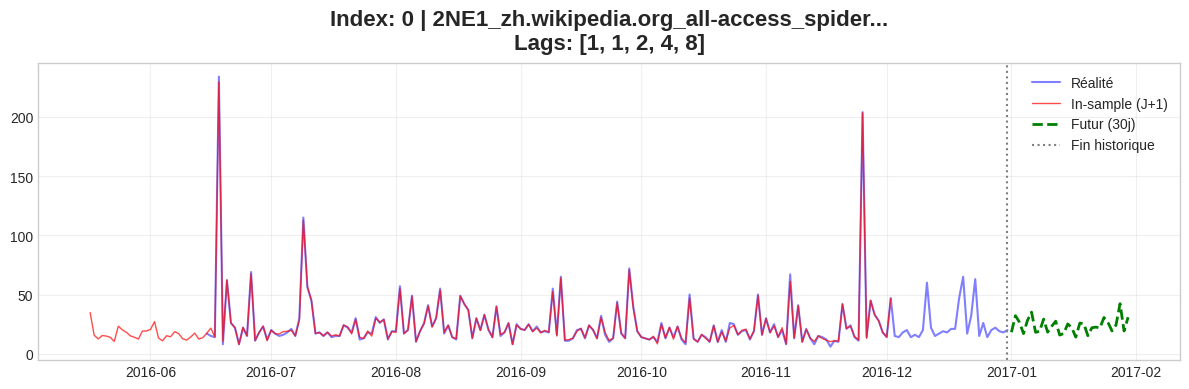

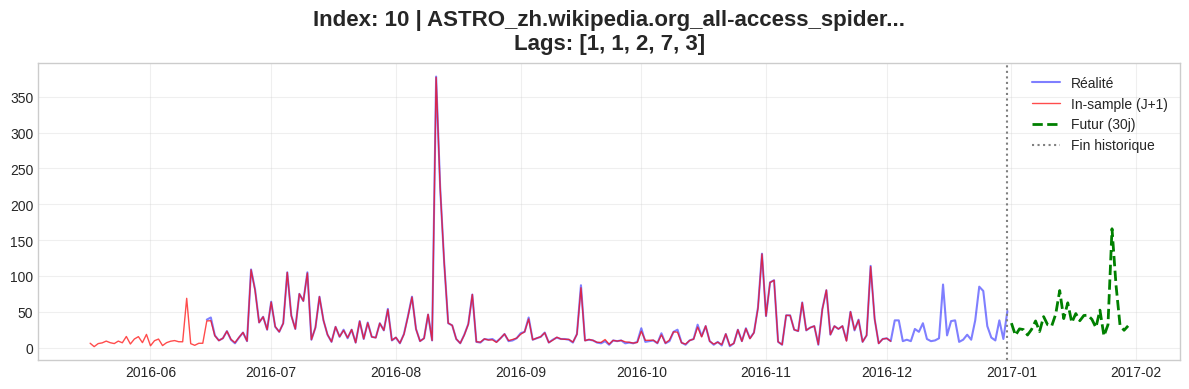

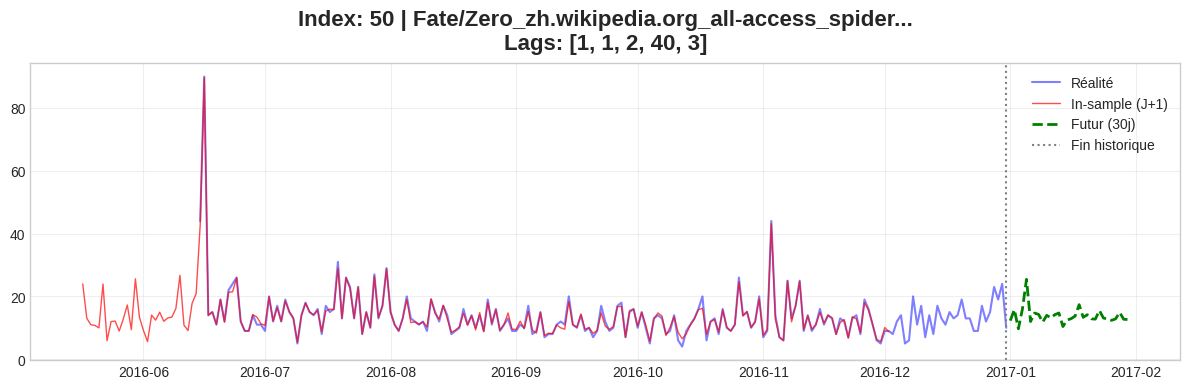

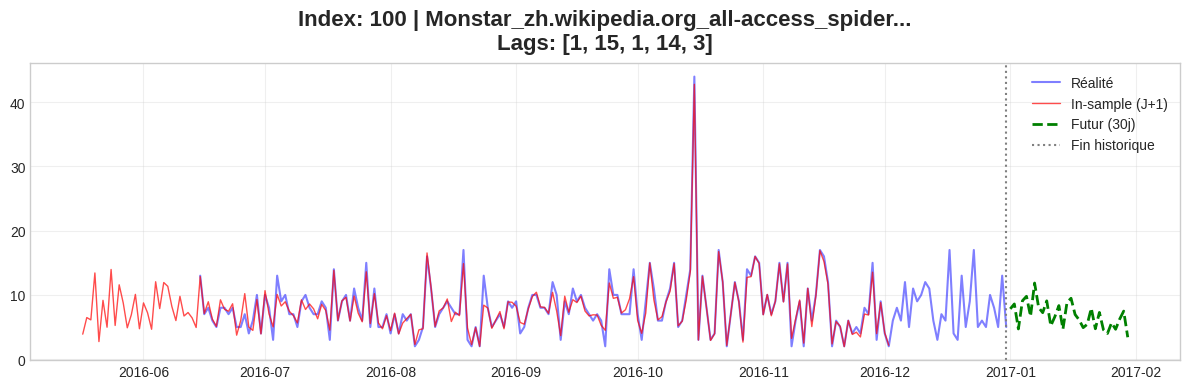

In [12]:
def forecast_article(index_article, n_forecast=30):
    ts = pd.to_numeric(train1.iloc[index_article, 1:], errors='coerce').fillna(0)
    ts.index = pd.to_datetime(train1.columns[1:])

    corrs = {i: abs(ts.corr(ts.shift(i))) for i in range(1, 60)}
    best_lags = [1] + sorted(corrs, key=corrs.get, reverse=True)[:4]

    X = pd.concat({f'y_lag_{i}': ts.shift(i) for i in best_lags}, axis=1).fillna(0.0)
    y = pd.concat({f'y_step_{i}': ts.shift(-i) for i in range(1, n_forecast + 1)}, axis=1)  # Commence à 1

    y_clean = y.dropna()
    X_clean = X.loc[y_clean.index]

    model = RegressorChain(base_estimator=XGBRegressor())
    model.fit(X_clean, y_clean)

    # Prédiction in-sample : on décale pour montrer J+1
    y_pred_values = model.predict(X_clean)[:, 0]  # Colonne 0 = J+1
    y_pred_index = y_clean.index + pd.Timedelta(days=1)  # Décaler d'un jour

    # Prédiction out-of-sample
    out_sample = model.predict(X.tail(1))[0]
    dates_futures = pd.date_range(ts.index[-1] + pd.Timedelta(days=1), periods=n_forecast)
    y_futur = pd.Series(out_sample, index=dates_futures).clip(0.0)

    # Affichage
    plt.figure(figsize=(12, 4))
    plt.plot(ts.index[-200:], ts.values[-200:], label='Réalité', color='blue', alpha=0.5)
    plt.plot(y_pred_index[-200:], y_pred_values[-200:], label='In-sample (J+1)', color='red', lw=1, alpha=0.7)
    plt.plot(y_futur.index, y_futur.values, label=f'Futur ({n_forecast}j)', color='green', ls='--', lw=2)
    plt.axvline(ts.index[-1], color='gray', ls=':', label='Fin historique')
    plt.title(f"Index: {index_article} | {train1.iloc[index_article, 0][:50]}...\nLags: {best_lags}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

for i in [0, 10, 50, 100]:
    forecast_article(i, n_forecast=30)

On créer notre fichier csv sur 465 pages wikipédia de train2 :

In [13]:
nb_pages_a_traiter = 500 
n_forecast = 64
all_predictions = []
last_date = pd.to_datetime(train2.columns[-1])

print("Début des pred...")
print("Format key2:", key2['Page'].iloc[0])
# On prépare les données de la première ligne pour le test
ts_sample = pd.to_numeric(train2.iloc[0, 1:], errors='coerce').fillna(0)
corrs_sample = {j: abs(ts_sample.corr(ts_sample.shift(j))) for j in range(1, 200)}
best_lags_sample = [1] + sorted(corrs_sample, key=corrs_sample.get, reverse=True)[:4]

X_sample = pd.concat({f'y_lag_{j}': ts_sample.shift(j) for j in best_lags_sample}, axis=1).fillna(0.0)
y_sample = pd.concat({f'y_step_{j}':ts_sample.shift(-j) for j in range(0,n_forecast)},axis=1)

y_sample_clean =  y_sample.dropna()
X_sample_clean = X_sample.loc[y_sample_clean.index]

# on utilise 'base_estimator__' car on est dans une RegressorChain
param_grid = {
    'base_estimator__n_estimators': [100, 200],
    'base_estimator__max_depth': [4, 6, 8],
    'base_estimator__learning_rate': [0.01, 0.05, 0.1],
    'base_estimator__subsample': [0.7, 0.9],
    'base_estimator__colsample_bytree': [0.7, 0.9]
}

# Initialisation du modèle de base
base_model = RegressorChain(base_estimator=XGBRegressor(n_jobs=-1))

# Recherche par grille
grid_search = GridSearchCV(base_model,param_grid, cv=3,scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_sample_clean, y_sample_clean)

best_params= grid_search.best_params_
print(f"Meilleurs paramètres trouvés : {best_params}")

# Boucle de pred
for i in range(nb_pages_a_traiter):
    # Préparation
    ts = pd.to_numeric(train2.iloc[i, 1:], errors='coerce').fillna(0)
    
    corrs = {j: abs(ts.corr(ts.shift(j))) for j in range(1, 200)}
    best_lags = [1, 7, 14, 21, 28] + sorted(corrs, key=corrs.get, reverse=True)[:3]
    best_lags = list(set(best_lags))  # Supprimer doublons
    
    X = pd.concat({f'y_lag_{j}': ts.shift(j) for j in best_lags}, axis=1).fillna(0.0)

    X['rolling_mean_7'] = ts.rolling(7).mean()
    X['rolling_mean_30'] = ts.rolling(30).mean()
    X['rolling_std_7'] = ts.rolling(7).std()
    dates_index = pd.to_datetime(train2.columns[1:])
    X['day_of_week'] = dates_index.dayofweek.values

    X.fillna(0.0, inplace=True)
    
    y = pd.concat({f'y_step_{j}': ts.shift(-j) for j in range(0, n_forecast)}, axis=1)
    
    y_clean = y.dropna()
    X_clean = X.loc[y_clean.index]
    # Modele
    xgb_params = {k.replace('base_estimator__', ''): v for k, v in best_params.items()}
    
    model = RegressorChain(base_estimator=XGBRegressor(**xgb_params, n_jobs=-1))
    model.fit(X_clean,y_clean)

    out_sample = model.predict(X.tail(1))[0].clip(0.0).round().astype(int)
    # Moyenne des 30 derniers jours comme filet de sécurité
    baseline = ts.tail(30).mean()
    out_sample = np.where(out_sample < 0, baseline, out_sample)

    nom_article = train2.iloc[i, 0]
    dates_futures = pd.date_range(last_date + pd.Timedelta(days=1), periods=n_forecast)
    
    for jour, valeur in enumerate(out_sample):
        all_predictions.append({
            'Page': f"{nom_article}_{dates_futures[jour].strftime('%Y-%m-%d')}",
            'Visits': int(valeur)
        })
print(f"Fin des prédictions.{len(all_predictions)}lignes générées.")

submission_df = pd.DataFrame(all_predictions)
key_df = key2 

 
final_submission = submission_df.merge(key_df, on='Page', how='left')
 
# On supprime les lignes qui n'ont pas trouve d'ID
missing_ids = final_submission['Id'].isnull().sum()
if missing_ids > 0:
    print(f"Attention : {missing_ids} prédictions retirées car ID introuvable.")
    final_submission = final_submission.dropna(subset=['Id'])
 
# On s'assure juste que c'est bien considére comme une string
final_submission['Id'] = final_submission['Id'].astype(str)

# Selection finale
final_submission = final_submission[['Id', 'Visits']]

# on sauvegarde
final_submission.to_csv('submission_final.csv',  index=False)

print(f"Fichier généré avec succès : {len(final_submission)} lignes.")

Début des pred...
Format key2: 007_スペクター_ja.wikipedia.org_all-access_all-agents_2017-09-13
Meilleurs paramètres trouvés : {'base_estimator__colsample_bytree': 0.7, 'base_estimator__learning_rate': 0.01, 'base_estimator__max_depth': 4, 'base_estimator__n_estimators': 100, 'base_estimator__subsample': 0.9}
Fin des prédictions.32000lignes générées.
Attention : 1000 prédictions retirées car ID introuvable.
Fichier généré avec succès : 31000 lignes.


Kaggle ne peut pas me donner de notes que pour 500 lignes, je vais m'évaluer moi-même.

In [14]:
def calculate_accuracy_score(y_true, y_pred):
    """
    Calcule une note de 0 à 1 basée sur le SMAPE (métrique officielle).
    1 = Parfait, 0 = Mauvais.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    denominator = (np.abs(y_true) + np.abs(y_pred))
    diff = np.abs(y_true - y_pred)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        smape_val = 200 * diff / denominator
        smape_val[denominator == 0] = 0.0
    
    mean_smape = np.mean(smape_val)
    
    accuracy = 1 - (mean_smape / 200)
    return max(0, accuracy)

n_test = 50 
all_scores = []

print(f"Évaluation de la précision sur {n_test} pages (Validation croisée)...")

for i in range(n_test):
    ts_full = pd.to_numeric(train2.iloc[i, 1:], errors='coerce').fillna(0)
    
    ts_train = ts_full[:-64]
    ts_real_val = ts_full[-64:].values

    
    corrs = {j: abs(ts_train.corr(ts_train.shift(j))) for j in range(1, 100)}
    best_lags = [1] + sorted(corrs, key=corrs.get, reverse=True)[:4]
    
    X = pd.concat({f'y_lag_{j}': ts_train.shift(j) for j in best_lags}, axis=1).fillna(0.0)
    y = pd.concat({f'y_step_{j}': ts_train.shift(-j) for j in range(0, 64)}, axis=1)
    
    y_clean = y.dropna()
    X_clean = X.loc[y_clean.index]
    
    xgb_params = {k.replace('base_estimator__', ''): v for k, v in best_params.items()}
    val_model = RegressorChain(base_estimator=XGBRegressor(**xgb_params, n_jobs=-1))
    val_model.fit(X_clean, y_clean)
    
    pred_val = val_model.predict(X.tail(1))[0].clip(0.0)

    score = calculate_accuracy_score(ts_real_val, pred_val)
    all_scores.append(score)

print("-" * 30)
print(f"NOTE DE PRÉCISION GLOBALE : {np.mean(all_scores):.4f} / 1.0000")
print("-" * 30)

Évaluation de la précision sur 50 pages (Validation croisée)...
------------------------------
NOTE DE PRÉCISION GLOBALE : 0.7704 / 1.0000
------------------------------


On a une note de 0.7704.